In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from clustering.leiden.fit import fit_leiden
from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings_224"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

2026-07-08 20:23:00.371548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


1664


In [2]:
embedding_l2 = normalize(embedding, norm="l2")

pca_85 = PCA(n_components=0.85)
pca_85_embedding = pca_85.fit_transform(embedding_l2)

In [6]:
from clustering.leiden.score import local_structure_per_cluster_consensus, consensus_param_metrics_leiden, \
    consensus_param_score_leiden
from clustering.leiden.consensus import consensus_clustering_from_labels_leiden
from clustering.leiden.params import make_umap_leiden_grid_params
from clustering.hdbscan.score import consensus_param_score, consensus_param_metrics
import pandas as pd
from tqdm.auto import tqdm


labels_for_consensus = []
umap_embeddings_for_consensus = []

for seed in range(0, 50):
    labels, _, _ = fit_leiden(
        X=pca_85_embedding,
        seed=None,
        k=max(15, round(0.035 * n_samples)) ,
        resolution=0.8
    )

    labels_for_consensus.append(labels)

consensus_labels, consensus_probabilities, diagnostics = consensus_clustering_from_labels_leiden(
    label_runs=labels_for_consensus,
    n_clusters="median",
    min_consensus_strength=0.60,
    mark_unstable_as_noise=True,
    return_diagnostics=True,
)



In [7]:
leiden_cluster_df = (
    pd.DataFrame({
        "cluster": consensus_labels,
        "probability": consensus_probabilities,
    })
    .groupby("cluster")
    .agg(
        size=("cluster", "size"),
        mean_probability=("probability", "mean"),
        median_probability=("probability", "median"),
        min_probability=("probability", "min"),
    )
    .reset_index()
    .sort_values("cluster")
)

leiden_cluster_df

,cluster,size,mean_probability,median_probability,min_probability
0,-1,11,0.000000,0.000000,0.000000
1,0,197,0.962353,0.975879,0.672663
2,1,86,0.837077,0.872791,0.641395
3,2,182,0.991682,0.995801,0.720442
4,3,151,0.939106,0.960645,0.658710
5,4,50,0.924800,0.952157,0.656863


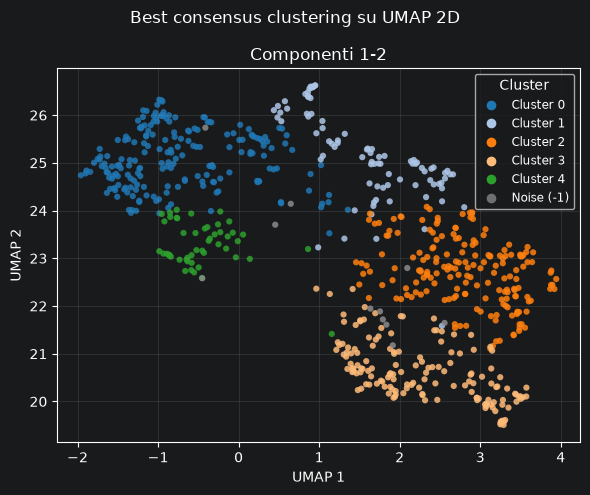

In [8]:
plot_figure, plot_axes = plot_clustering_on_umap(
    pca_85_embedding,
    consensus_labels,
    title="Best consensus clustering su UMAP 2D",
    metric="euclidean",
    min_dist=0.02,
    n_neighbors=max(15, round(0.05 * n_samples)),
)

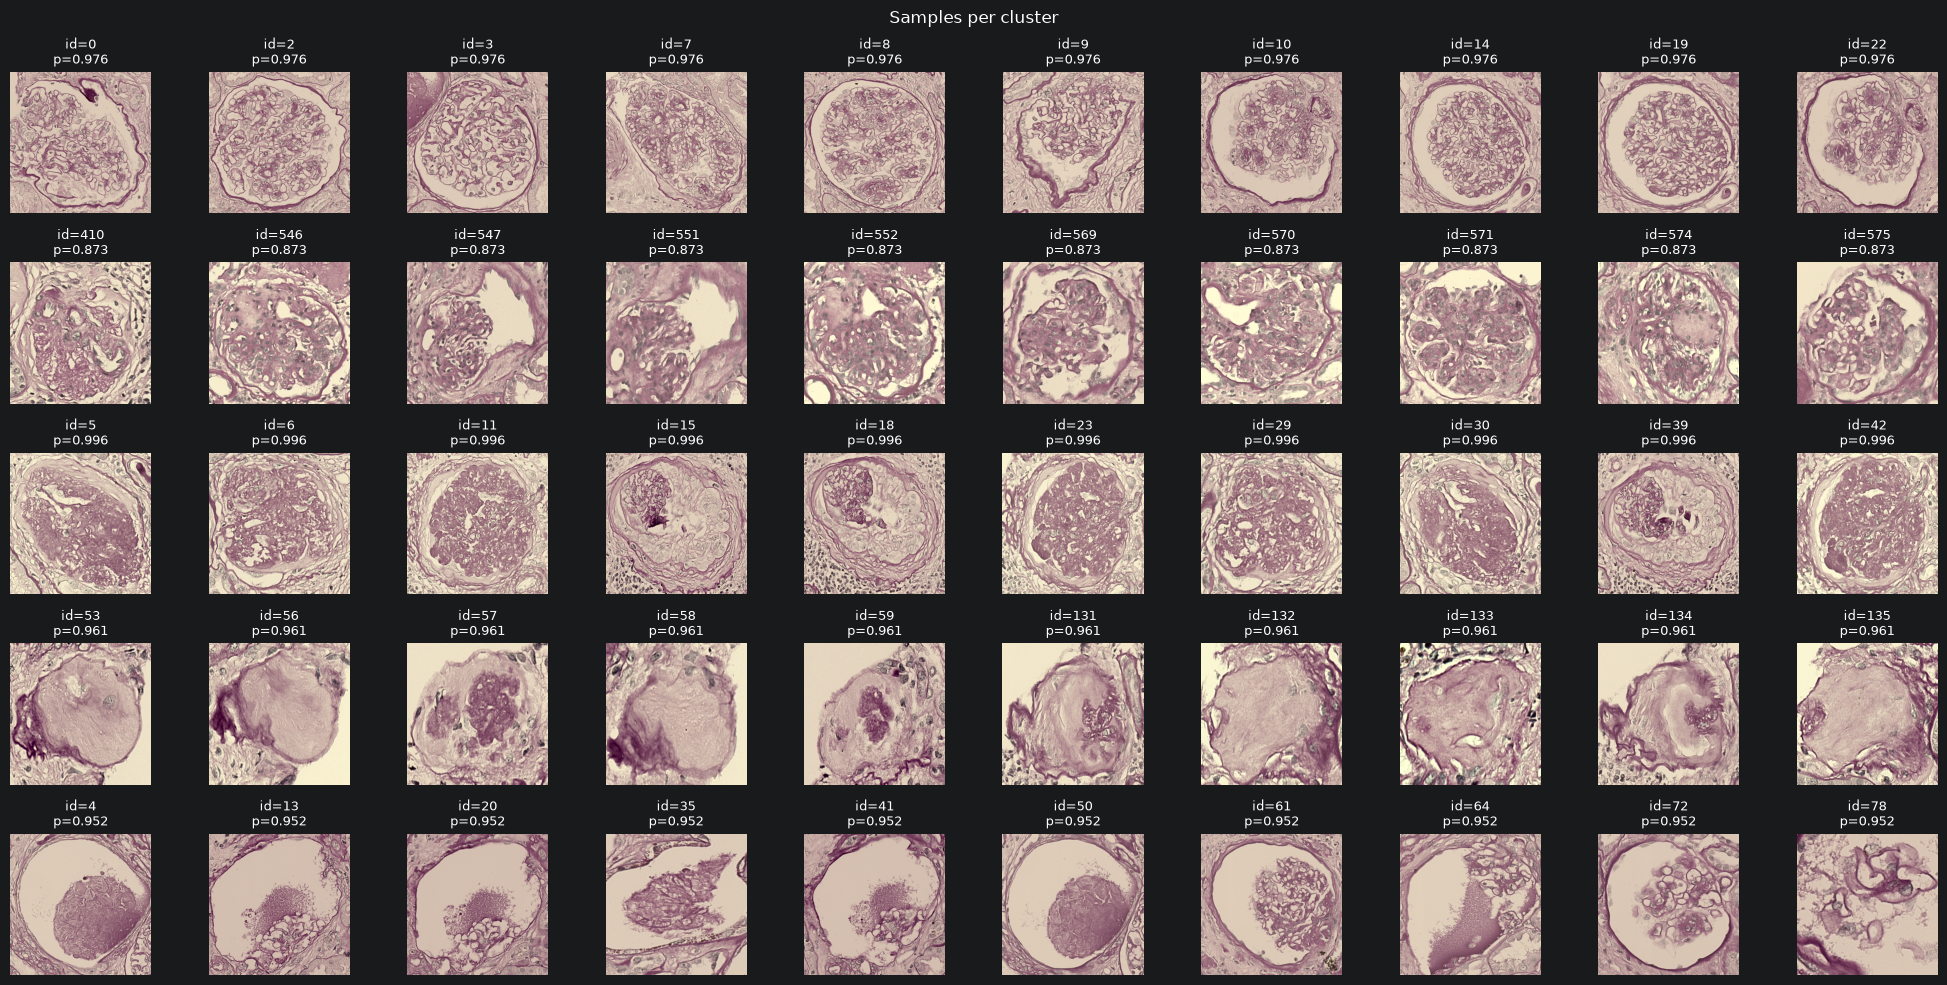

In [9]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=consensus_labels,
    probabilities=consensus_probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [11]:
ID_SCLEROTIC = 4
ID_OPEN = 3

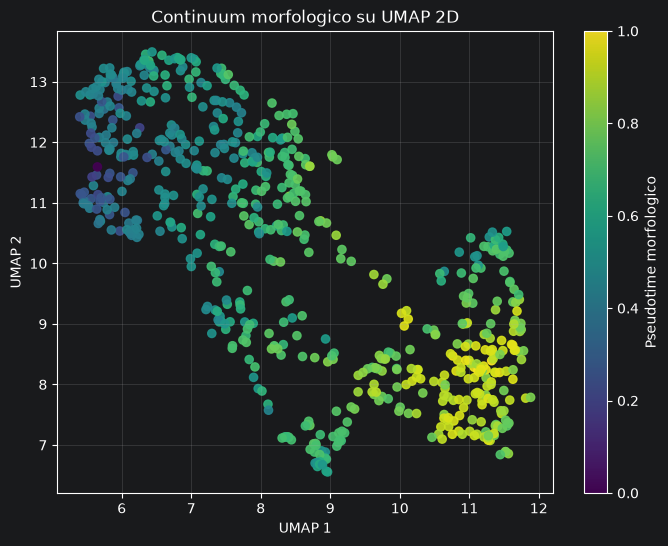

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=pseudotime,
    s=35,
    cmap="viridis",
    alpha=0.9,
)

plt.colorbar(sc, label="Pseudotime morfologico")
plt.title("Continuum morfologico su UMAP 2D")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()

In [23]:
import pandas as pd

cluster_order_df = pd.DataFrame({
    "cluster": best_consensus_labels,
    "pseudotime": pseudotime,
})

cluster_order_df = (
    cluster_order_df
    .groupby("cluster")
    .agg(
        n_samples=("pseudotime", "size"),
        pseudotime_mean=("pseudotime", "mean"),
        pseudotime_median=("pseudotime", "median"),
        pseudotime_min=("pseudotime", "min"),
        pseudotime_max=("pseudotime", "max"),
    )
    .sort_values("pseudotime_median")
    .reset_index()
)

cluster_order_df

,cluster,n_samples,pseudotime_mean,pseudotime_median,pseudotime_min,pseudotime_max
0,4,227,0.455996,0.461707,0.000000,0.716866
1,0,36,0.640024,0.681356,0.489410,0.753605
2,1,98,0.659492,0.685620,0.455384,0.814139
3,3,112,0.662013,0.686802,0.443345,0.848548
4,2,204,0.859455,0.879047,0.685864,1.000000


In [24]:
import numpy as np
import pandas as pd

# Rimuovi eventuale riga global
cluster_order_df_clean = cluster_order_df[
    cluster_order_df["cluster"] != "global"
    ].copy()

# Forza i cluster a interi
cluster_order_df_clean["cluster"] = pd.to_numeric(
    cluster_order_df_clean["cluster"]
).astype(int)

# Lista ordinata dei cluster originali
ordered_clusters = cluster_order_df_clean["cluster"].tolist()

# Dizionario cluster originale -> stage ordinato
cluster_to_stage = {
    int(cluster): int(stage)
    for stage, cluster in enumerate(ordered_clusters)
}

# Crea stage labels
stage_labels = np.array([
    cluster_to_stage[int(c)]
    for c in best_consensus_labels
], dtype=int)

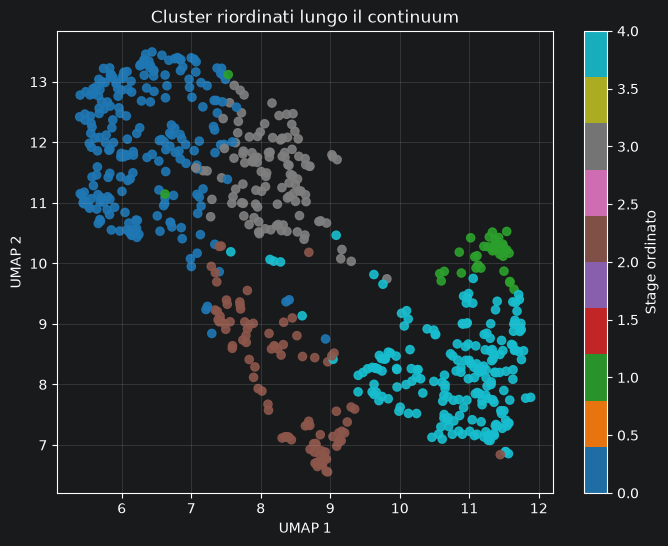

In [25]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=stage_labels,
    s=35,
    cmap="tab10",
    alpha=0.9,
)

plt.colorbar(sc, label="Stage ordinato")
plt.title("Cluster riordinati lungo il continuum")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()

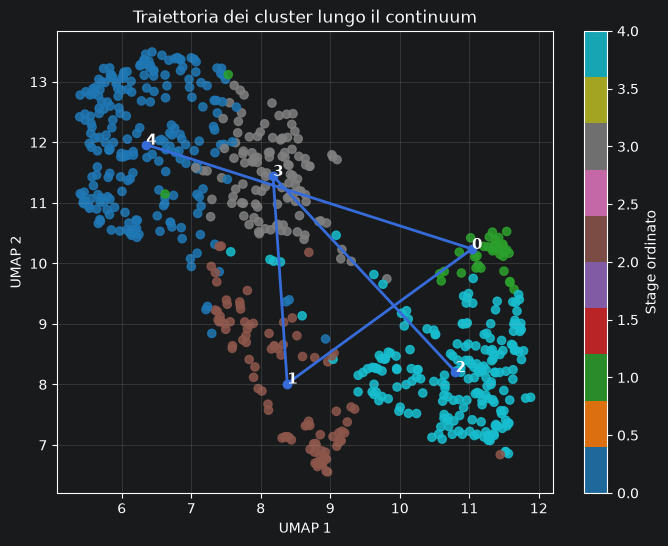

In [26]:
cluster_centroids = []

for cluster_id in ordered_clusters:
    idx = np.where(best_consensus_labels == cluster_id)[0]

    centroid = umap_2d[idx].mean(axis=0)

    cluster_centroids.append({
        "cluster": cluster_id,
        "x": centroid[0],
        "y": centroid[1],
    })

centroids_df = pd.DataFrame(cluster_centroids)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=stage_labels,
    s=35,
    cmap="tab10",
    alpha=0.85,
)

plt.plot(
    centroids_df["x"],
    centroids_df["y"],
    linewidth=2,
    marker="o",
)

for _, row in centroids_df.iterrows():
    plt.text(
        row["x"],
        row["y"],
        str(int(row["cluster"])),
        fontsize=11,
        weight="bold",
    )

plt.colorbar(sc, label="Stage ordinato")
plt.title("Traiettoria dei cluster lungo il continuum")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()